# Дополнительное задание. Прогнозирование временных рядов

**Дисциплина:** Методы анализа данных · **Выполнил:** Савченко В.Э., гр. АВТ-313

**Цель:** освоить базовый пайплайн прогнозирования временного ряда через сведение к задаче регрессии.

**Данные:** дневное потребление электроэнергии в Германии за 2006–2017 гг.
([Open Power System Data](https://open-power-system-data.org/), выгрузка
[opsd_germany_daily.csv](https://github.com/jenfly/opsd)), 4 383 наблюдения.
Целевая переменная — `Consumption`, суточное потребление, ГВт·ч.

**Почему этот ряд:** в нём есть всё, что требует задание — недельная и годовая сезонность,
слабый тренд, праздники и выбросы, — и его длины (12 лет) хватает, чтобы честно оценить модель
на целом отложенном годе.

## Содержание

1. Загрузка и визуализация
2. STL-декомпозиция
3. Признаки (без утечки из будущего)
4. Разделение по времени и кросс-валидация
5. Модели: прогноз на 1 шаг вперёд
6. Анализ ошибок
7. Признаки на основе декомпозиции
8. Прогноз на горизонт H = 14 дней: рекурсивная и прямая стратегии
9. Выводы и ограничения

**Метрики** (y — факт, ŷ — прогноз, n — число точек):

| Метрика | Формула | Смысл |
|---|---|---|
| MSE | (1/n)·Σ(y−ŷ)² | средний квадрат ошибки, сильнее штрафует крупные промахи |
| RMSE | √MSE | то же в ГВт·ч |
| MAE | (1/n)·Σ\|y−ŷ\| | средняя абсолютная ошибка, ГВт·ч |
| MAPE | (100 %/n)·Σ\|y−ŷ\|/\|y\| | средняя относительная ошибка |
| WAPE | 100 %·Σ\|y−ŷ\| / Σ\|y\| | суммарная ошибка относительно суммарного объёма; не «взрывается» на малых y и взвешивает дни по объёму |

In [1]:
# Импорт библиотек
import os
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.easter import easter                      # дата Пасхи -> подвижные праздники

from statsmodels.tsa.seasonal import STL, MSTL          # STL и многосезонная STL
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
pd.set_option("display.width", 140)

os.makedirs("figs", exist_ok=True)
def show(fig, name):
    """Сохраняет рисунок в figs/ и выводит его в ноутбуке."""
    fig.tight_layout()
    fig.savefig(f"figs/{name}.png", bbox_inches="tight")
    plt.show()

# 1. Загрузка и визуализация

Столбец `Date` приводится к типу `datetime`, ряд сортируется по времени и получает явную
дневную частоту (`asfreq("D")`) — так пропущенные даты, если бы они были, стали бы видны как NaN,
а все сдвиги `shift(k)` означают ровно k дней.

In [2]:
# Загрузка: дневное потребление электроэнергии в Германии, ГВт·ч (Open Power System Data)
CSV = "opsd_germany_daily.csv"
URL = "https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv"
if not os.path.exists(CSV):
    urllib.request.urlretrieve(URL, CSV)

df = pd.read_csv(CSV)
df["Date"] = pd.to_datetime(df["Date"])          # строка -> datetime
df = df.sort_values("Date").set_index("Date")    # сортировка по времени, дата -> индекс
s = df["Consumption"].asfreq("D")                # явная дневная частота: пропущенные даты станут NaN

print("Период:", s.index.min().date(), "—", s.index.max().date())
print("Наблюдений:", len(s), "| пропусков:", s.isna().sum(),
      "| дубликатов дат:", df.index.duplicated().sum())
s.describe().round(1)

Период: 2006-01-01 — 2017-12-31
Наблюдений: 4383 | пропусков: 0 | дубликатов дат: 0


count    4383.0
mean     1338.7
std       165.8
min       842.4
25%      1217.9
50%      1367.1
75%      1457.8
max      1709.6
Name: Consumption, dtype: float64

Ряд полный: 4 383 дня без пропусков и дубликатов дат. Среднее потребление 1 339 ГВт·ч в сутки,
стандартное отклонение 166 ГВт·ч (12 % от среднего), диапазон 842–1 710 ГВт·ч.

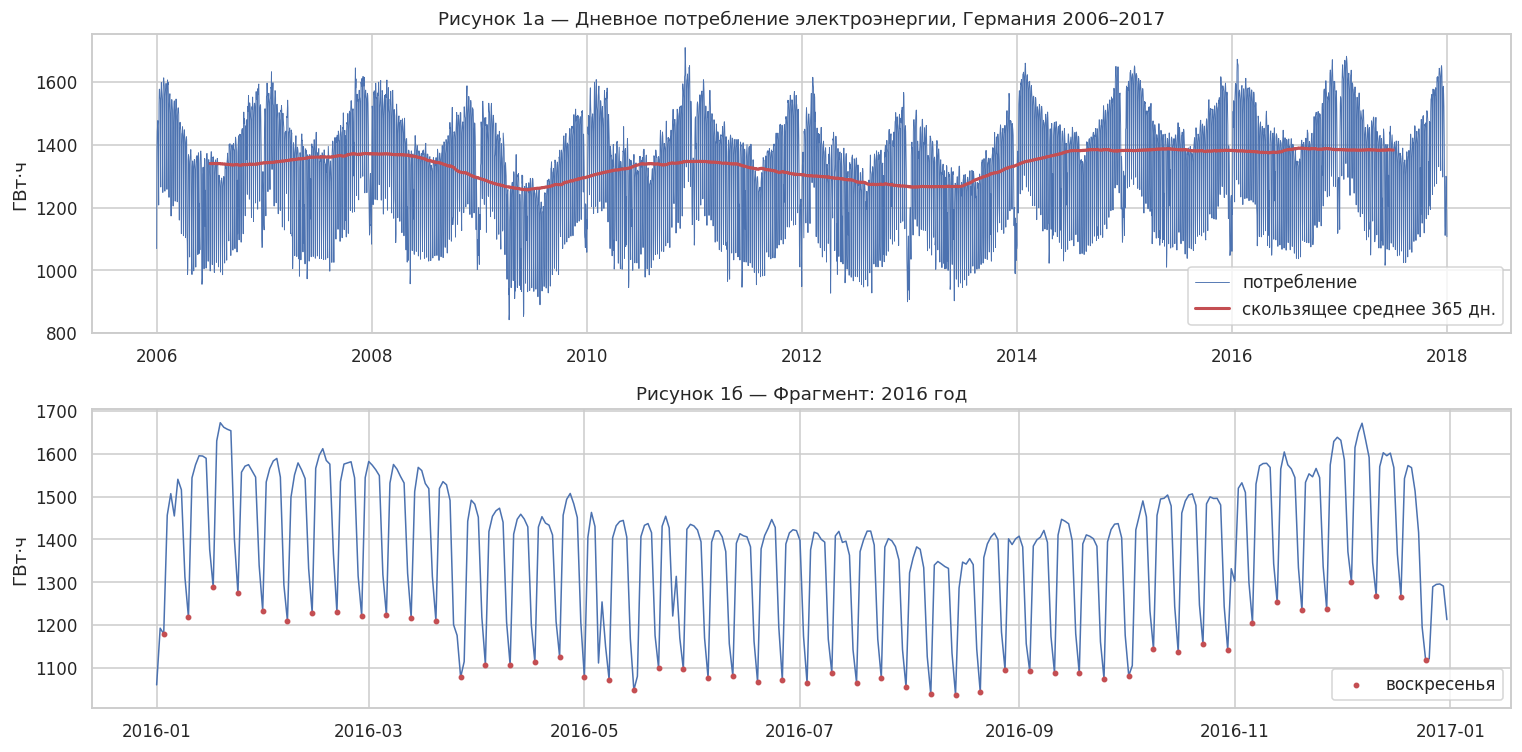

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
# весь ряд + скользящее среднее за год (показывает тренд)
axes[0].plot(s, lw=0.6, color="#4C72B0", label="потребление")
axes[0].plot(s.rolling(365, center=True).mean(), color="#C44E52", lw=2, label="скользящее среднее 365 дн.")
axes[0].set_title("Рисунок 1а — Дневное потребление электроэнергии, Германия 2006–2017")
axes[0].set_ylabel("ГВт·ч"); axes[0].legend()
# один год крупно: видна недельная «пила» и провалы в праздники
y16 = s["2016"]
axes[1].plot(y16, lw=1, color="#4C72B0")
axes[1].scatter(y16.index[y16.index.dayofweek == 6], y16[y16.index.dayofweek == 6],
                s=8, color="#C44E52", label="воскресенья", zorder=3)
axes[1].set_title("Рисунок 1б — Фрагмент: 2016 год"); axes[1].set_ylabel("ГВт·ч"); axes[1].legend()
show(fig, "01_series")

**Комментарий к рисунку 1.**

- **Тренд** слабый и немонотонный: годовое скользящее среднее держится около 1 340 ГВт·ч,
  с заметным провалом в 2009 году (−7 % к 2008-му — экономический кризис) и ступенькой вверх
  в 2014-м (с 1 269 до 1 381 ГВт·ч). Это скорее смена уровня, чем устойчивый рост.
- **Годовая сезонность** выражена: зимой потребление выше (отопление, освещение), летом ниже —
  ряд «дышит» с периодом год.
- **Недельная сезонность** — самая сильная: на фрагменте 2016 года ряд имеет вид «пилы»,
  нижние зубцы — воскресенья (красные точки).
- **Выбросы** — резкие провалы, не совпадающие с воскресеньями: праздники (Пасха, Рождество,
  1 мая) и особенно период между Рождеством и Новым годом.

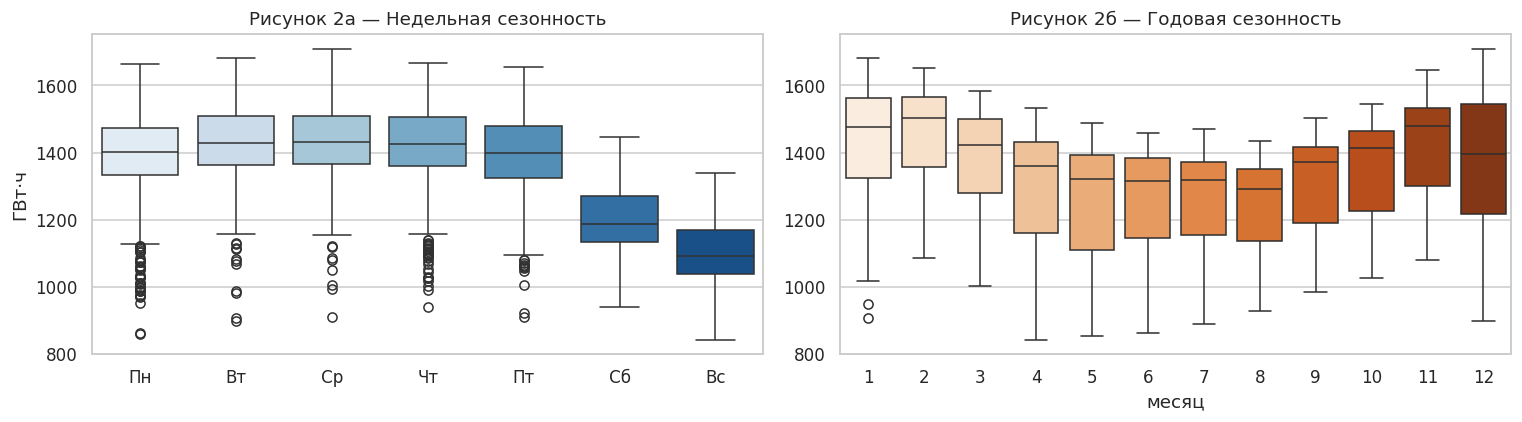

Медиана по дням недели:
dow
0    1401.0
1    1427.0
2    1431.0
3    1425.0
4    1399.0
5    1187.0
6    1093.0

Медиана по месяцам:
month
1     1477.0
2     1503.0
3     1421.0
4     1359.0
5     1321.0
6     1317.0
7     1319.0
8     1292.0
9     1373.0
10    1413.0
11    1478.0
12    1395.0

Среднее по годам:
Date
2006    1339.9
2007    1360.6
2008    1354.0
2009    1259.6
2010    1338.6
2011    1328.3
2012    1283.0
2013    1269.4
2014    1381.3
2015    1384.3
2016    1382.3
2017    1382.8


In [4]:
tmp = pd.DataFrame({"y": s, "dow": s.index.dayofweek, "month": s.index.month})
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=tmp, x="dow", y="y", ax=axes[0], palette="Blues")
axes[0].set_xticklabels(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"])
axes[0].set_title("Рисунок 2а — Недельная сезонность"); axes[0].set_xlabel(""); axes[0].set_ylabel("ГВт·ч")
sns.boxplot(data=tmp, x="month", y="y", ax=axes[1], palette="Oranges")
axes[1].set_title("Рисунок 2б — Годовая сезонность"); axes[1].set_xlabel("месяц"); axes[1].set_ylabel("")
show(fig, "02_seasonality")

print("Медиана по дням недели:"); print(tmp.groupby("dow")["y"].median().round(0).to_string())
print("\nМедиана по месяцам:"); print(tmp.groupby("month")["y"].median().round(0).to_string())
print("\nСреднее по годам:"); print(s.groupby(s.index.year).mean().round(1).to_string())

**Комментарий к рисунку 2.**

- *Недельная сезонность:* будни Пн–Пт почти одинаковы (медиана 1 399–1 431 ГВт·ч), суббота
  на 16 % ниже будней (1 187), воскресенье — на 23 % ниже (1 093). Понедельник и пятница чуть
  ниже вторника–четверга: «разгон» и «сворачивание» рабочей недели.
- *Годовая сезонность:* максимум в январе–феврале и ноябре (≈ 1 480–1 500), минимум в августе
  (1 292) — на 14 % ниже февраля. Декабрь выбивается вниз (1 395) из-за рождественских каникул:
  по сезонной логике он должен быть на уровне ноября.
- У будних дней много точек-выбросов снизу (до 860–1 000 ГВт·ч) — это праздники, выпавшие на будни:
  в праздник потребление падает до воскресного уровня. Ящики месяцев широкие, потому что смешивают
  будни и выходные; самый широкий — декабрь (рождественские каникулы). Именно в эти дни стоит
  ожидать наибольших ошибок модели.

**Вывод по разделу:** тренд слабый (смены уровня), сезонность двойная — недельная (сильнее)
и годовая, выбросы связаны в основном с праздниками. Значит, модели нужны: календарные признаки
(день недели, праздники), недельные лаги и значение год назад.

Аномальных дней (|robust z| > 5): 300 из 4383 (6.8 %)
  официальные праздники:      103  (из 108 праздников в ряду)
  период 24.12–01.01:         67
  соседние с праздником дни:  37
  прочие:                     93


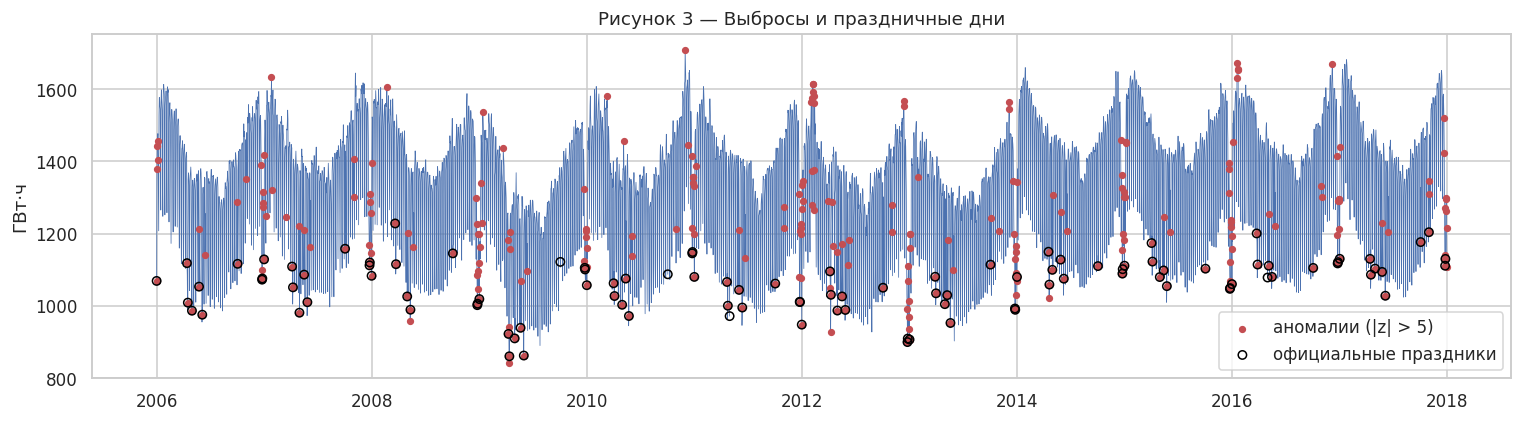

In [5]:
def de_holidays(years):
    """Общегерманские праздники: фиксированные + привязанные к Пасхе."""
    h = {}
    for y in years:
        e = pd.Timestamp(easter(y))
        h.update({
            pd.Timestamp(y, 1, 1): "Новый год",
            e - pd.Timedelta(days=2): "Страстная пятница",
            e + pd.Timedelta(days=1): "Пасхальный понедельник",
            pd.Timestamp(y, 5, 1): "День труда",
            e + pd.Timedelta(days=39): "Вознесение",
            e + pd.Timedelta(days=50): "Духов день",
            pd.Timestamp(y, 10, 3): "День единства",
            pd.Timestamp(y, 12, 25): "Рождество",
            pd.Timestamp(y, 12, 26): "2-й день Рождества",
        })
        if y == 2017:
            h[pd.Timestamp(2017, 10, 31)] = "День Реформации (500 лет)"
    return pd.Series(h).sort_index()

HOL = de_holidays(range(2005, 2019))
is_hol = s.index.isin(HOL.index)

# Выбросы: отклонение от медианы того же дня недели за ±3 недели (робастная z-оценка)
same_dow_med = s.groupby(s.index.dayofweek).transform(
    lambda x: x.rolling(7, center=True, min_periods=3).median())
dev = s - same_dow_med
mad = (dev - dev.median()).abs().median()
z = 0.6745 * (dev - dev.median()) / mad
out = z.abs() > 5
xmas = ((s.index.month == 12) & (s.index.day >= 24)) | ((s.index.month == 1) & (s.index.day == 1))
near = (s.index - pd.Timedelta(days=1)).isin(HOL.index) | (s.index + pd.Timedelta(days=1)).isin(HOL.index)
print(f"Аномальных дней (|robust z| > 5): {out.sum()} из {len(s)} ({out.mean()*100:.1f} %)")
print(f"  официальные праздники:      {(out & is_hol).sum()}  (из {is_hol.sum()} праздников в ряду)")
print(f"  период 24.12–01.01:         {(out & xmas & ~is_hol).sum()}")
print(f"  соседние с праздником дни:  {(out & near & ~is_hol & ~xmas).sum()}")
print(f"  прочие:                     {(out & ~near & ~is_hol & ~xmas).sum()}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s, lw=0.5, color="#4C72B0")
ax.scatter(s.index[out], s[out], color="#C44E52", s=14, zorder=3, label="аномалии (|z| > 5)")
ax.scatter(s.index[is_hol], s[is_hol], facecolors="none", edgecolors="black", s=30,
           zorder=4, label="официальные праздники")
ax.set_title("Рисунок 3 — Выбросы и праздничные дни"); ax.set_ylabel("ГВт·ч"); ax.legend()
show(fig, "03_outliers")

**Комментарий к рисунку 3.** Выбросы искались робастно: каждое значение сравнивалось с медианой
того же дня недели за ±3 недели, отклонение нормировалось на MAD (медианное абсолютное
отклонение — устойчивый аналог σ). Порог |z| > 5.

Из 300 аномальных дней (6,8 %) **207 объясняются календарём**: 103 официальных праздника
(из 108 в ряду — почти каждый праздник является выбросом), 67 дней периода 24.12–01.01 и 37
дней, соседних с праздником. Это **не ошибки данных, а предсказуемые события**, поэтому их
не удаляем, а описываем признаками `is_holiday`, `holiday_prev/next`, `bridge_day`,
`xmas_period`. Оставшиеся 93 тоже в основном календарные, но не попавшие в общегерманский список:
региональные праздники (Крещение 6 января, Праздник Тела Христова — четверг в июне, с «мостиком»
в пятницу, День всех святых 1 ноября), предрождественские 22–23 декабря и первые рабочие дни
января (вместе декабрь и январь дают 48 из 93); ещё 23 приходятся на 2012 год со сменой уровня ряда.

# 2. STL-декомпозиция

STL (Seasonal-Trend decomposition using LOESS) раскладывает ряд в сумму
**y = тренд + сезонность + остаток**, оценивая компоненты локальной регрессией. У нашего ряда
две сезонности, поэтому применяется **MSTL** — многосезонный вариант STL, который итеративно
выделяет сезонность с периодом 7 и с периодом 365 дней.

Здесь декомпозиция строится по всему ряду — это **описательный анализ**. Для признаков модели
(раздел 7) декомпозиция будет считаться только по обучающему периоду.

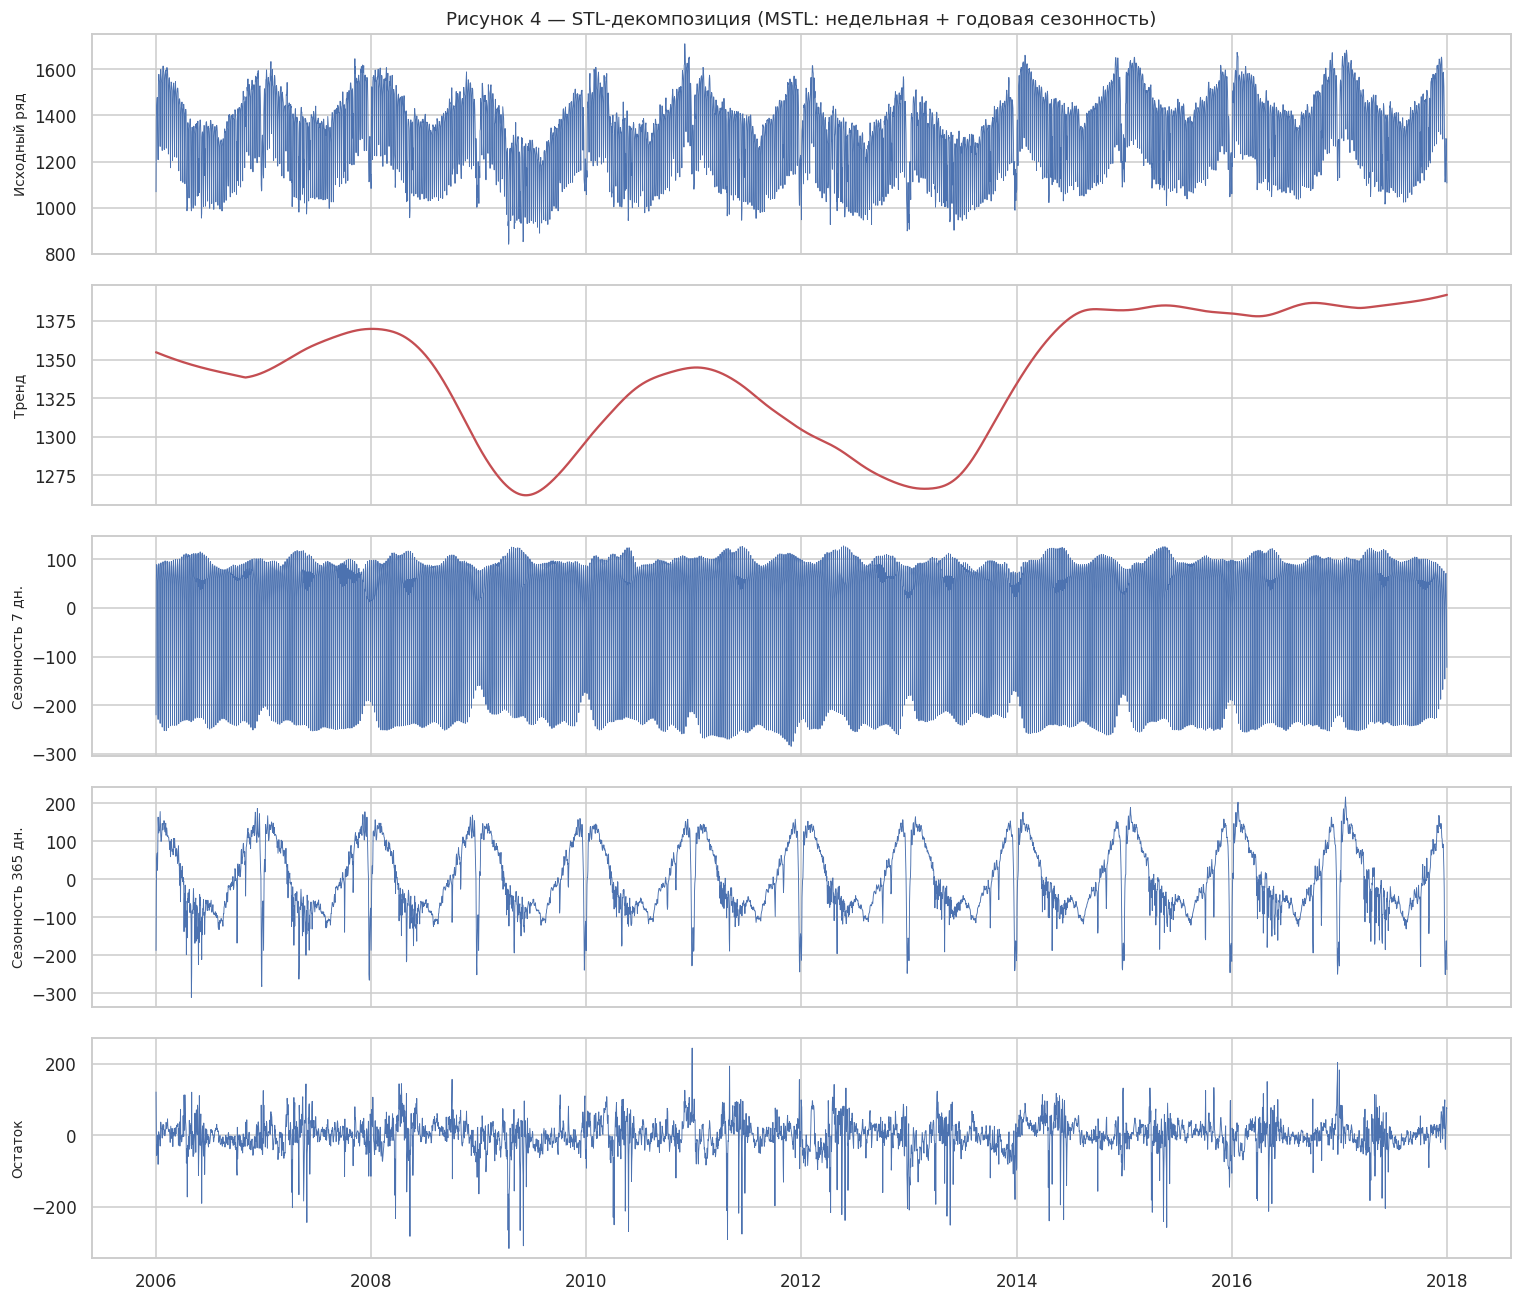

Сила тренда:            0.479
Сила недельной сезонн.:  0.879
Сила годовой сезонн.:    0.795

Амплитуда (размах) компонент, ГВт·ч:
  Тренд                  129.9   (std 40.3)
  Сезонность 7 дн.       411.5   (std 123.2)
  Сезонность 365 дн.     527.8   (std 90.1)
  Остаток                561.2   (std 45.9)


In [6]:
# Декомпозиция для анализа (описательная, по всему ряду).
# Две сезонности -> MSTL: итеративное применение STL для периодов 7 и 365 дней.
mstl_full = MSTL(s, periods=(7, 365)).fit()
comp = pd.DataFrame({"Исходный ряд": s, "Тренд": mstl_full.trend,
                     "Сезонность 7 дн.": mstl_full.seasonal["seasonal_7"],
                     "Сезонность 365 дн.": mstl_full.seasonal["seasonal_365"],
                     "Остаток": mstl_full.resid})
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
for ax, (name, col) in zip(axes, comp.items()):
    ax.plot(col, lw=0.6 if name != "Тренд" else 1.5,
            color="#C44E52" if name == "Тренд" else "#4C72B0")
    ax.set_ylabel(name, fontsize=9)
axes[0].set_title("Рисунок 4 — STL-декомпозиция (MSTL: недельная + годовая сезонность)")
show(fig, "04_stl")

def strength(seas, resid):
    """Сила компоненты по Хайндману: 1 - Var(R)/Var(S+R); > 0.6 — выраженная."""
    return max(0.0, 1 - resid.var() / (seas + resid).var())

R = mstl_full.resid
print(f"Сила тренда:            {strength(mstl_full.trend, R):.3f}")
print(f"Сила недельной сезонн.:  {strength(mstl_full.seasonal['seasonal_7'], R):.3f}")
print(f"Сила годовой сезонн.:    {strength(mstl_full.seasonal['seasonal_365'], R):.3f}")
print(f"\nАмплитуда (размах) компонент, ГВт·ч:")
for c in ["Тренд", "Сезонность 7 дн.", "Сезонность 365 дн.", "Остаток"]:
    print(f"  {c:20s} {comp[c].max() - comp[c].min():7.1f}   (std {comp[c].std():.1f})")

**Комментарий к рисунку 4.**

- **Тренд** (красная линия) меняется в узком коридоре — размах 130 ГВт·ч при std 40; видны
  провал 2009 года и подъём 2014-го. Сила тренда 0,48 — умеренная.
- **Недельная сезонность** — самая сильная компонента: сила **0,88**, размах 412 ГВт·ч. Амплитуда
  «пилы» по месяцам почти постоянна (≈ 330–360 ГВт·ч) — недельный цикл устойчив в течение года.
- **Годовая сезонность** — сила **0,80**, размах 528 ГВт·ч; провал в конце декабря модель
  частично «впитала» в сезонность, поскольку он повторяется каждый год.
- **Остаток** небольшой (std 46 ГВт·ч, 3,4 % от среднего), но с редкими глубокими выбросами —
  это подвижные праздники (Пасха, Вознесение, Духов день): они каждый год на разной дате,
  поэтому годовая сезонность их не ловит.

Сила компоненты считается по Хайндману: F = max(0, 1 − Var(R)/Var(S+R)); значения выше 0,6
означают выраженную компоненту. **Обе сезонности сильные — модели нужны признаки на обе.**

# 3. Признаки (без утечки из будущего)

Прогноз на день t делается в конце дня t−1, поэтому **каждый признак строки t может использовать
только значения y до t−1 включительно**. Все признаки строятся через `shift(k)` с k ≥ 1,
а скользящие окна применяются к уже сдвинутому ряду `y.shift(1).rolling(w)` — если поставить
сдвиг после `rolling`, окно захватит текущее значение и возникнет утечка.

| Группа | Признаки | Почему без утечки |
|---|---|---|
| Календарные (29) | год, день года, sin/cos дня года, one-hot дня недели и месяца, выходной, праздник, канун и день после праздника, «мостик», период 24.12–01.01 | календарь известен заранее для любой даты |
| Лаги (10) | y[t−1] … y[t−7], y[t−14], y[t−21], y[t−28] | сдвиг ≥ 1 |
| Скользящие (11) | среднее, медиана, std, min, max за 7 и 30 дней; изменение за неделю y[t−1] − y[t−8] | окно по `y.shift(1)` |
| Сезонные (3) | y[t−364] (тот же день недели год назад), y[t−365], среднее за неделю вокруг t−364 | сдвиг ≥ 361 |

Суточной сезонности нет (данные дневные), поэтому сезонные признаки — недельные лаги
(y[t−7], y[t−14], …) и годовые (y[t−364]). y[t−364] предпочтительнее y[t−365]: 364 = 52·7,
то есть это **тот же день недели** год назад.

In [7]:
LAGS = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
WINDOWS = [7, 30]

def calendar_features(idx):
    """Календарные признаки: известны заранее для любой даты, утечки нет."""
    X = pd.DataFrame(index=idx)
    X["year"] = idx.year
    X["dayofyear"] = idx.dayofyear
    X["doy_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)   # гладкая годовая
    X["doy_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)   # сезонность
    for k in range(7):                                           # one-hot дня недели
        X[f"dow_{k}"] = (idx.dayofweek == k).astype(int)         # (явно, чтобы набор
    for m in range(1, 13):                                       #  столбцов не зависел
        X[f"month_{m}"] = (idx.month == m).astype(int)           #  от куска данных)
    X["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    hol = idx.isin(HOL.index)
    X["is_holiday"] = hol.astype(int)
    X["holiday_prev"] = (idx - pd.Timedelta(days=1)).isin(HOL.index).astype(int)  # день после праздника
    X["holiday_next"] = (idx + pd.Timedelta(days=1)).isin(HOL.index).astype(int)  # канун праздника
    X["bridge_day"] = (((idx.dayofweek == 0) & X["holiday_next"].astype(bool)) |   # «мостик» между
                       ((idx.dayofweek == 4) & X["holiday_prev"].astype(bool))).astype(int)  # праздником и выходными
    X["xmas_period"] = (((idx.month == 12) & (idx.day >= 24)) |
                        ((idx.month == 1) & (idx.day == 1))).astype(int)
    return X

def past_features(y):
    """Лаги и скользящие статистики. Строка t использует ТОЛЬКО y[..t-1]."""
    X = pd.DataFrame(index=y.index)
    for L in LAGS:
        X[f"lag_{L}"] = y.shift(L)
    y1 = y.shift(1)                                   # сдвиг ДО rolling — ключ к отсутствию утечки
    for w in WINDOWS:
        r = y1.rolling(w)
        X[f"roll_mean_{w}"] = r.mean()
        X[f"roll_median_{w}"] = r.median()
        X[f"roll_std_{w}"] = r.std()
        X[f"roll_min_{w}"] = r.min()
        X[f"roll_max_{w}"] = r.max()
    X["diff_1_7"] = y.shift(1) - y.shift(8)           # изменение за неделю
    return X

def seasonal_features(y):
    """Значение ряда неделю/год назад. lag_364 = тот же день недели год назад."""
    X = pd.DataFrame(index=y.index)
    X["lag_364"] = y.shift(364)
    X["lag_365"] = y.shift(365)
    X["year_ago_week_mean"] = y.shift(361).rolling(7).mean()   # среднее за t-367..t-361
    return X

def build_features(y):
    return pd.concat([calendar_features(y.index), past_features(y), seasonal_features(y)], axis=1)

F = build_features(s)
data = F.assign(y=s).dropna()                         # первые 368 дней без лагов отбрасываем
FEATS = list(F.columns)
CAL = list(calendar_features(s.index[:1]).columns)
PAST = list(past_features(s.iloc[:10]).columns)
SEAS = list(seasonal_features(s.iloc[:10]).columns)
print(f"Признаков: {len(FEATS)}  (календарные {len(CAL)}, лаги/скользящие {len(PAST)}, сезонные {len(SEAS)})")
print("Данные для обучения:", data.index.min().date(), "—", data.index.max().date(), f"({len(data)} строк)")
data[["y", "lag_1", "lag_7", "roll_mean_7", "roll_std_7", "lag_364", "is_holiday", "dow_6"]].head()

Признаков: 53  (календарные 29, лаги/скользящие 21, сезонные 3)
Данные для обучения: 2007-01-03 — 2017-12-31 (4016 строк)


,y,lag_1,lag_7,roll_mean_7,roll_std_7,lag_364,is_holiday,dow_6
Date,,,,,,,,
2007-01-03,1471.586,1416.669,1284.676,1257.369429,99.467443,1457.217,0,0
2007-01-04,1514.823,1471.586,1314.603,1284.070857,128.785972,1477.131,0,0
2007-01-05,1484.168,1514.823,1274.646,1312.673714,156.046166,1403.427,0,0
2007-01-06,1249.663,1484.168,1237.751,1342.605429,167.230014,1300.287,0,0
2007-01-07,1173.687,1249.663,1144.398,1344.307143,166.041581,1207.985,0,1


Получено 53 признака. Первые 368 дней (2006 год и 2 дня 2007-го) отброшены: для них нет значения
год назад. Осталось 4 016 строк.

Ниже — **формальная проверка отсутствия утечки**: значения ряда начиная с даты t₀ заменяются
нулями, и признаки строки t₀ пересчитываются. Если они не изменились — признаки действительно
используют только прошлое.

In [8]:
# Проверка отсутствия утечки: признаки строки t не должны меняться,
# если «испортить» значения ряда начиная с момента t.
t0 = pd.Timestamp("2015-06-15")
y_bad = s.copy(); y_bad[t0:] = 0.0
F_bad = build_features(y_bad)
same = np.allclose(F.loc[t0, FEATS].astype(float), F_bad.loc[t0, FEATS].astype(float))
print(f"Признаки на {t0.date()} не зависят от y[t0:] -> {same}")

Признаки на 2015-06-15 не зависят от y[t0:] -> True


# 4. Разделение по времени и кросс-валидация

Перемешивать временной ряд нельзя: модель увидела бы «будущее» в обучении, а соседние дни
почти одинаковы, и оценка качества была бы завышена. Поэтому:

- **test** — последний год целиком, 2017 (365 дней): покрывает все сезоны и праздники;
- **train** — 2007–2016 (3 651 день);
- **кросс-валидация — расширяющееся окно** (`TimeSeriesSplit`, 5 фолдов, валидационный блок —
  365 дней): модель всегда обучается на прошлом и проверяется на следующем году, а обучающая
  часть с каждым фолдом растёт. Валидация длиной в год, чтобы в каждый блок попадали все сезоны.

train: 2007-01-03 — 2016-12-31  (3651 дней)
test:  2017-01-01 — 2017-12-31  (365 дней)
фолд 1: train 2007-01-03…2012-01-02 (1826) | valid 2012-01-03…2013-01-01
фолд 2: train 2007-01-03…2013-01-01 (2191) | valid 2013-01-02…2014-01-01
фолд 3: train 2007-01-03…2014-01-01 (2556) | valid 2014-01-02…2015-01-01
фолд 4: train 2007-01-03…2015-01-01 (2921) | valid 2015-01-02…2016-01-01
фолд 5: train 2007-01-03…2016-01-01 (3286) | valid 2016-01-02…2016-12-31


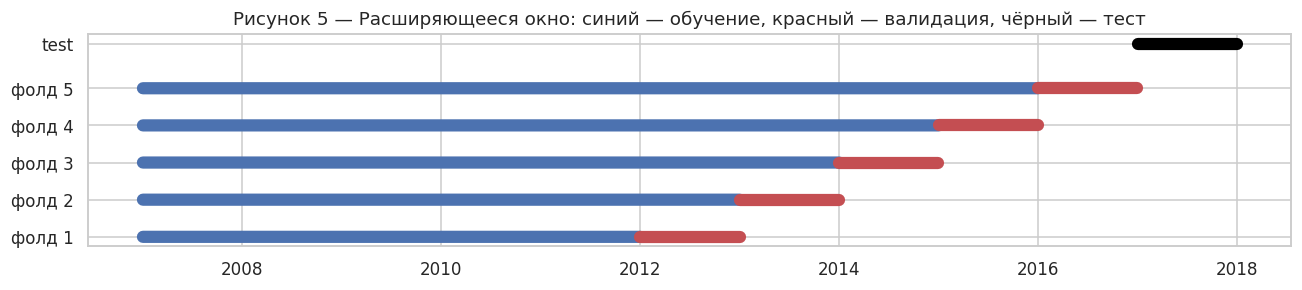

In [9]:
TEST_START = "2017-01-01"
train = data[:"2016-12-31"]
test = data[TEST_START:]
X_tr, y_tr = train[FEATS], train["y"]
X_te, y_te = test[FEATS], test["y"]
print(f"train: {train.index.min().date()} — {train.index.max().date()}  ({len(train)} дней)")
print(f"test:  {test.index.min().date()} — {test.index.max().date()}  ({len(test)} дней)")

# Кросс-валидация с расширяющимся окном: 5 фолдов, валидация — каждый раз следующий год
tscv = TimeSeriesSplit(n_splits=5, test_size=365)
fig, ax = plt.subplots(figsize=(12, 2.8))
for i, (tr_i, va_i) in enumerate(tscv.split(X_tr)):
    ax.plot(train.index[tr_i], [i] * len(tr_i), color="#4C72B0", lw=8)
    ax.plot(train.index[va_i], [i] * len(va_i), color="#C44E52", lw=8)
    print(f"фолд {i+1}: train {train.index[tr_i[0]].date()}…{train.index[tr_i[-1]].date()} "
          f"({len(tr_i)}) | valid {train.index[va_i[0]].date()}…{train.index[va_i[-1]].date()}")
ax.plot(test.index, [5.2] * len(test), color="black", lw=8)
ax.set_yticks(list(range(5)) + [5.2]); ax.set_yticklabels([f"фолд {i+1}" for i in range(5)] + ["test"])
ax.set_title("Рисунок 5 — Расширяющееся окно: синий — обучение, красный — валидация, чёрный — тест")
show(fig, "05_cv")

**Комментарий к рисунку 5.** Каждый фолд — честная имитация реального использования: обучение
только на прошлом (синее), проверка на следующих 365 днях (красное). Тестовый 2017 год (чёрное)
не участвует ни в обучении, ни в подборе гиперпараметров.

# 5. Модели: прогноз на 1 шаг вперёд

Сравниваются четыре модели:

1. **Наивный прогноз** y[t−1] — «завтра как сегодня»;
2. **Сезонный наивный** y[t−7] — «как в этот же день неделю назад»; это главный ориентир:
   модель, которая его не обыгрывает, бесполезна;
3. **Ridge-регрессия** со стандартизацией внутри `Pipeline` (масштабирование переобучается
   в каждом фолде — утечки через scaler нет); alpha подбирается по временной CV;
4. **Градиентный бустинг** (`HistGradientBoostingRegressor`) — улавливает нелинейности
   и взаимодействия признаков (например, «понедельник × праздник»).

In [10]:
def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    e = y - p
    return {"MSE": np.mean(e ** 2),
            "RMSE": np.sqrt(np.mean(e ** 2)),
            "MAE": np.mean(np.abs(e)),
            "MAPE, %": np.mean(np.abs(e) / np.abs(y)) * 100,
            "WAPE, %": np.abs(e).sum() / np.abs(y).sum() * 100}

def cv_score(model, X, y, cv=tscv):
    """Среднее MAE и MAPE по фолдам временной кросс-валидации."""
    maes, mapes = [], []
    for tr_i, va_i in cv.split(X):
        model.fit(X.iloc[tr_i], y.iloc[tr_i])
        m = metrics(y.iloc[va_i], model.predict(X.iloc[va_i]))
        maes.append(m["MAE"]); mapes.append(m["MAPE, %"])
    return np.mean(maes), np.std(maes), np.mean(mapes)

In [11]:
# Ridge: подбор alpha по временной CV (масштабирование внутри Pipeline -> без утечки по фолдам)
ridge_gs = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("m", Ridge())]),
    {"m__alpha": np.logspace(-4, 3, 29)}, cv=tscv, scoring="neg_mean_absolute_error")
ridge_gs.fit(X_tr, y_tr)
ALPHA = ridge_gs.best_params_["m__alpha"]
print(f"Ridge: лучшее alpha = {ALPHA:.4g} (нижняя граница сетки 1e-4)")

def make_ridge():
    return Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=ALPHA))])

def make_hgb():
    return HistGradientBoostingRegressor(max_iter=600, learning_rate=0.04, max_leaf_nodes=31,
                                         min_samples_leaf=20, l2_regularization=1.0,
                                         random_state=RANDOM_STATE)

rows, preds_te = [], {}
# Базовые модели (бейзлайны) — без обучения
for name, col in [("Наивный (y[t-1])", "lag_1"), ("Сезонный наивный (y[t-7])", "lag_7")]:
    preds_te[name] = X_te[col]
    rows.append({"Модель": name, "Выборка": "train", **metrics(y_tr, X_tr[col])})
    rows.append({"Модель": name, "Выборка": "test", **metrics(y_te, X_te[col])})

for name, make in [("Ridge", make_ridge), ("Градиентный бустинг", make_hgb)]:
    cv_mae, cv_std, cv_mape = cv_score(make(), X_tr, y_tr)
    m = make().fit(X_tr, y_tr)
    preds_te[name] = pd.Series(m.predict(X_te), index=X_te.index)
    rows.append({"Модель": name, "Выборка": "train", **metrics(y_tr, m.predict(X_tr))})
    rows.append({"Модель": name, "Выборка": "CV (5 фолдов)", "MAE": cv_mae, "MAPE, %": cv_mape})
    rows.append({"Модель": name, "Выборка": "test", **metrics(y_te, preds_te[name])})
    print(f"{name}: CV MAE = {cv_mae:.1f} ± {cv_std:.1f}, CV MAPE = {cv_mape:.2f} %")
    if name == "Ridge": ridge = m
    else: hgb = m

res1 = pd.DataFrame(rows).set_index(["Модель", "Выборка"])
print("\nТаблица 1 — Прогноз на 1 шаг вперёд")
res1.round(2)

Ridge: лучшее alpha = 0.0001 (нижняя граница сетки 1e-4)
Ridge: CV MAE = 21.5 ± 2.6, CV MAPE = 1.67 %


Градиентный бустинг: CV MAE = 22.6 ± 5.4, CV MAPE = 1.74 %

Таблица 1 — Прогноз на 1 шаг вперёд


MSE    RMSE     MAE  MAPE, %  WAPE, %
Модель                    Выборка                                                  
Наивный (y[t-1])          train          22465.72  149.89  103.17     8.08     7.73
                          test           22248.04  149.16  102.34     7.73     7.40
Сезонный наивный (y[t-7]) train           8513.21   92.27   51.92     4.06     3.89
                          test            9350.76   96.70   54.10     4.04     3.91
Ridge                     train           1167.96   34.18   22.09     1.73     1.66
                          CV (5 фолдов)       NaN     NaN   21.45     1.67      NaN
                          test             871.09   29.51   18.62     1.40     1.35
Градиентный бустинг       train             80.67    8.98    6.63     0.51     0.50
                          CV (5 фолдов)       NaN     NaN   22.57     1.74      NaN
                          test             567.56   23.82   16.47     1.21     1.19

**Интерпретация таблицы 1.**

- **Бейзлайны.** Наивный прогноз ошибается на 7,7 % — он не знает про недельный цикл и после
  воскресенья предсказывает «воскресное» потребление на понедельник. Сезонный наивный вдвое
  лучше — 4,0 %. Это подтверждает: главная структура ряда — недельная.
- **Обе ML-модели обыгрывают сезонный наивный в 3 раза:** MAPE на тесте 1,40 % (Ridge)
  и 1,21 % (бустинг) против 4,04 %. Средняя ошибка 16–19 ГВт·ч при среднем потреблении
  1 383 ГВт·ч. Для суточного прогноза энергопотребления это хороший уровень: промышленные
  системы прогноза дают порядка 1–3 %.
- **Ridge:** подбор дал alpha на нижней границе сетки (10⁻⁴) — регуляризация не нужна, Ridge
  фактически совпадает с обычной линейной регрессией. Это закономерно: 3 651 наблюдение
  на 53 признака. Ошибки train (1,73 %), CV (1,67 %) и test (1,40 %) близки — **переобучения нет**.
- **Бустинг:** на train MAPE 0,51 %, на CV 1,74 %, на test 1,21 %. Огромный разрыв train/CV
  означает, что бустинг **запоминает** обучающую выборку — признак переобучения. Но качество
  на новых данных при этом не хуже, чем у Ridge, поэтому правильная оценка — CV и test,
  а не train. Разброс бустинга по фолдам (± 5,4 ГВт·ч) вдвое больше, чем у Ridge (± 2,6) —
  он менее стабилен.
- **Test лучше CV у обеих моделей.** Причина — CV усредняет 5 лет, а ошибка по фолдам падает
  по мере роста обучающей выборки: Ridge 2,08 → 1,85 → 1,54 → 1,42 → 1,46 %, бустинг
  2,37 → 1,92 → 1,98 → 1,20 → 1,22 %. Худший фолд 1 — модель обучена всего на 5 годах
  и проверяется на 2012-м со сменой уровня ряда. Тестовая модель обучена на всех 10 годах,
  а 2017 год «спокойный» — уровень как в 2014–2016. Бустинг сильнее выигрывает от объёма данных.
- **По CV модели равны** (1,67 % против 1,74 %), **по тесту бустинг лучше** (1,21 % против 1,40 %).
  Лучшей считаю бустинг по тесту, но с оговоркой о его меньшей стабильности.

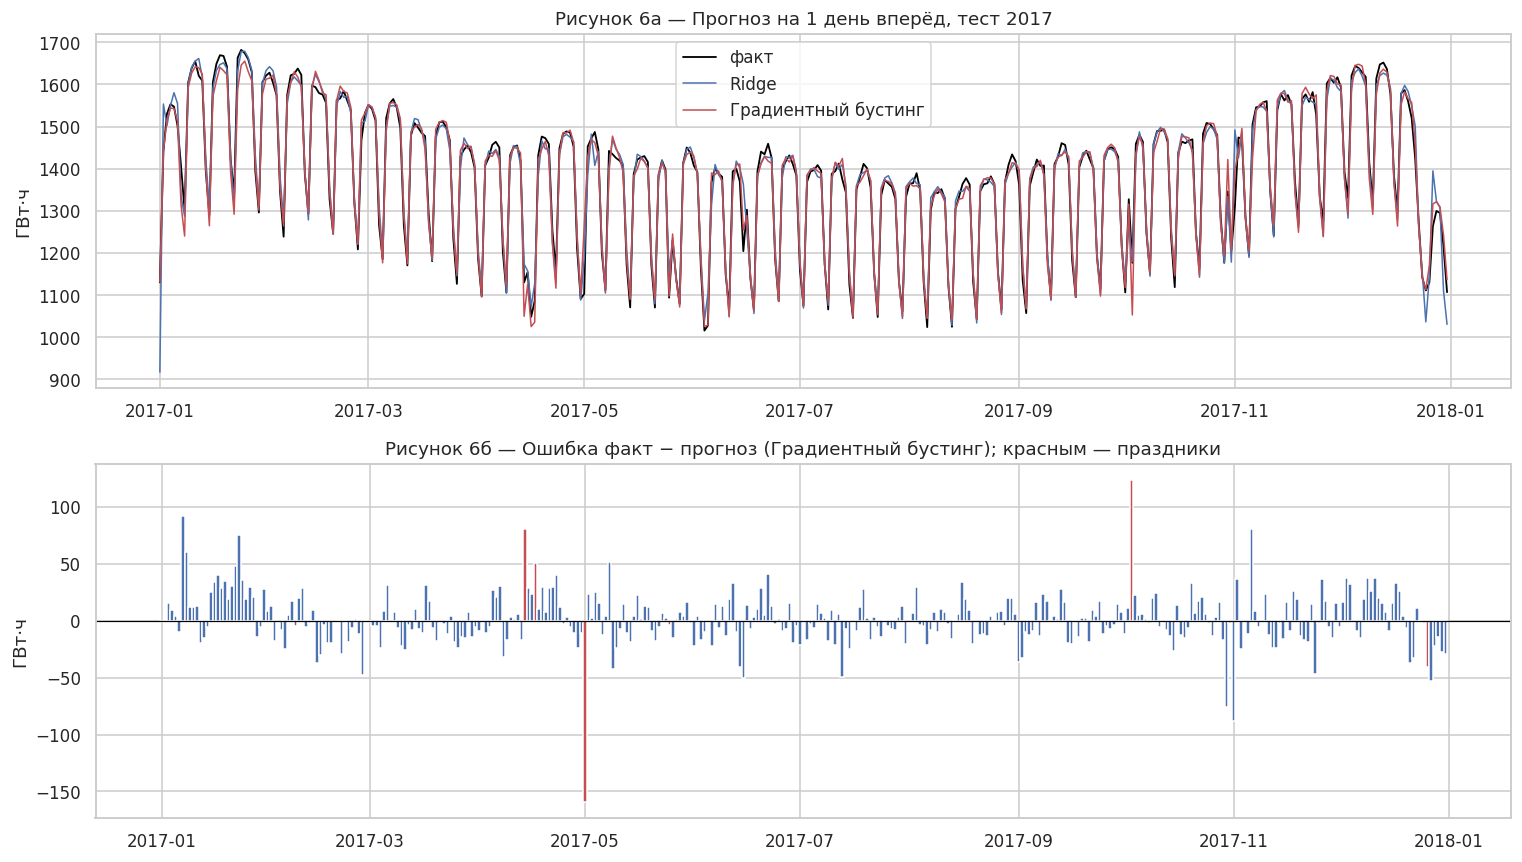

Лучшая модель на тесте: Градиентный бустинг


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(y_te, color="black", lw=1.2, label="факт")
axes[0].plot(preds_te["Ridge"], color="#4C72B0", lw=1, label="Ridge")
axes[0].plot(preds_te["Градиентный бустинг"], color="#C44E52", lw=1, label="Градиентный бустинг")
axes[0].set_title("Рисунок 6а — Прогноз на 1 день вперёд, тест 2017"); axes[0].legend(); axes[0].set_ylabel("ГВт·ч")
best = "Ridge" if res1.loc[("Ridge", "test"), "MAE"] <= res1.loc[("Градиентный бустинг", "test"), "MAE"] else "Градиентный бустинг"
err = y_te - preds_te[best]
axes[1].bar(err.index, err.values, width=1, color=np.where(X_te["is_holiday"] == 1, "#C44E52", "#4C72B0"))
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"Рисунок 6б — Ошибка факт − прогноз ({best}); красным — праздники"); axes[1].set_ylabel("ГВт·ч")
show(fig, "06_test_1step")
print("Лучшая модель на тесте:", best)

**Комментарий к рисунку 6.** Прогнозы обеих моделей визуально почти совпадают с фактом:
недельная «пила» и годовая волна воспроизведены. Ошибки (нижний график) в обычные дни лежат
в коридоре ±30 ГВт·ч, а крупные столбцы — это красные столбцы праздников и дни вокруг них.
90 % ошибок обычных будних дней лежат в интервале от −26 до +33 ГВт·ч. На большинстве праздников
2017 года модель точна (Новый год, Вознесение, Духов день, День Реформации, Рождество — ошибка
до 4 ГВт·ч), крупные промахи — на пяти из десяти, причём в **обе стороны**: 1 мая и 26 декабря
модель недооценила падение (прогноз выше факта на 160 и 40 ГВт·ч), а в Страстную пятницу,
Пасхальный понедельник и 3 октября — переоценила (прогноз ниже на 80, 50 и 124 ГВт·ч).

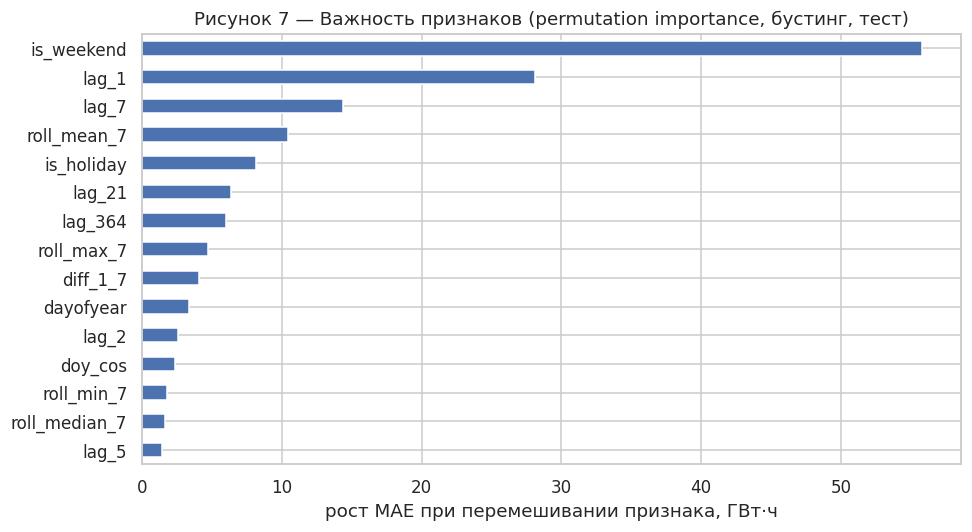

,ΔMAE
is_weekend,55.82
lag_1,28.14
lag_7,14.37
roll_mean_7,10.47
is_holiday,8.19
lag_21,6.34
lag_364,6.03
roll_max_7,4.71
diff_1_7,4.08
dayofyear,3.37


In [13]:
pi = permutation_importance(hgb, X_te, y_te, n_repeats=5, random_state=RANDOM_STATE,
                            scoring="neg_mean_absolute_error")
imp = pd.Series(pi.importances_mean, index=FEATS).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
imp[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("рост MAE при перемешивании признака, ГВт·ч")
ax.set_title("Рисунок 7 — Важность признаков (permutation importance, бустинг, тест)")
show(fig, "07_importance")
imp.round(2).to_frame("ΔMAE")

**Комментарий к рисунку 7.** Важность измерялась перестановкой: признак перемешивается на тесте,
и смотрится, насколько выросла MAE. Самые важные:

1. `is_weekend` (+56 ГВт·ч) — выходной/будний день, главный фактор недельной сезонности;
2. `lag_1` (+28) — вчерашнее значение задаёт текущий уровень;
3. `lag_7` (+14) — тот же день неделю назад;
4. `roll_mean_7` (+10) — средний уровень за неделю, сглаженная оценка тренда;
5. `is_holiday` (+8) — праздники.

Годовые признаки (`lag_364`, `dayofyear`, `doy_cos`) тоже в топе, но их вклад меньше: годовой
цикл меняется медленно, и его во многом «переносят» `lag_1` и `roll_mean_7`. Признаки года
(`year`) нет в топе — тренд слабый.

# 6. Анализ ошибок

Где модель ошибается сильнее — на тренде, сезонности или выбросах? Разбиваем ошибки теста
по дню недели, месяцу и типу дня.

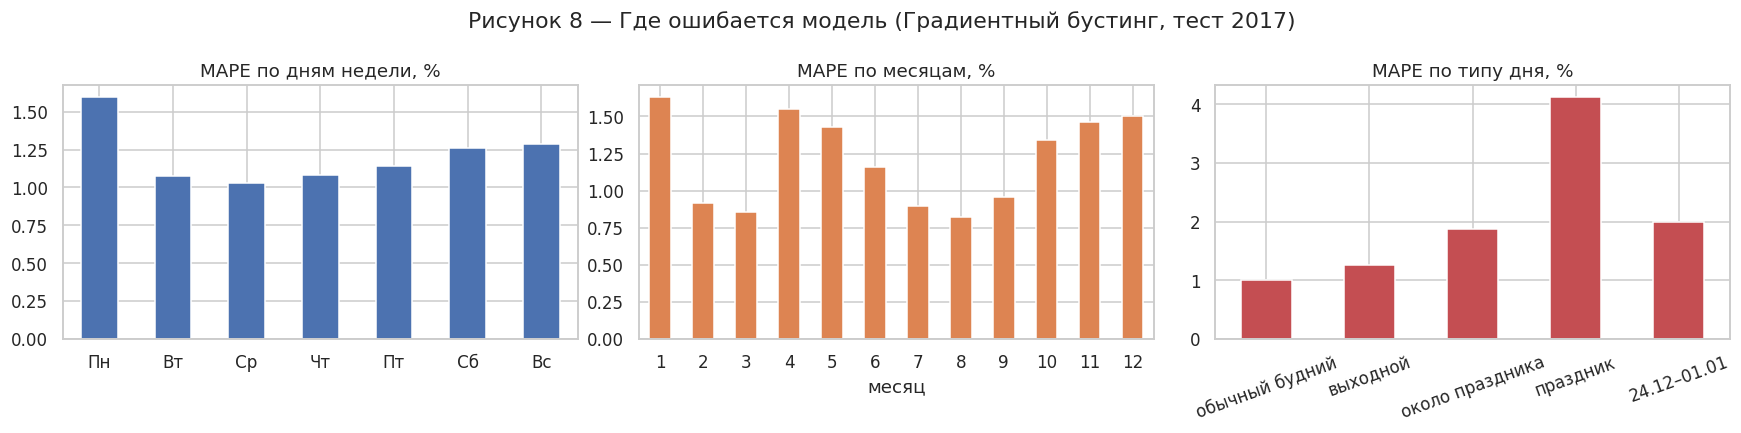

Вклад типов дней в суммарную ошибку:
                 дней  MAPE  сумма_ошибки  доля_ошибки, %
тип дня                                                  
обычный будний    237   1.0        3544.0            59.0
выходной           97   1.3        1493.2            24.8
около праздника    15   1.9         362.9             6.0
праздник           10   4.1         464.3             7.7
24.12–01.01         6   2.0         146.3             2.4

Топ-10 худших дней:
                 y       p  abs_err   ape       день           праздник
Date                                                                   
2017-05-01  1103.2  1262.9    159.7  14.5     Monday         День труда
2017-10-03  1176.8  1053.1    123.7  10.5    Tuesday      День единства
2017-01-07  1405.1  1313.2     92.0   6.5   Saturday                   
2017-11-01  1309.2  1397.1     88.0   6.7  Wednesday                   
2017-11-06  1505.7  1424.7     80.9   5.4     Monday                   
2017-04-14  1130.3  1049.8     8

In [14]:
an = pd.DataFrame({"y": y_te, "p": preds_te[best]})
an["abs_err"] = (an.y - an.p).abs()
an["ape"] = an.abs_err / an.y * 100
an["dow"] = an.index.dayofweek
an["month"] = an.index.month
an["тип дня"] = np.select(
    [X_te["is_holiday"] == 1, X_te["xmas_period"] == 1,
     (X_te["holiday_prev"] == 1) | (X_te["holiday_next"] == 1) | (X_te["bridge_day"] == 1),
     X_te["is_weekend"] == 1],
    ["праздник", "24.12–01.01", "около праздника", "выходной"], "обычный будний")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
an.groupby("dow")["ape"].mean().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_xticklabels(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"], rotation=0)
axes[0].set_title("MAPE по дням недели, %"); axes[0].set_xlabel("")
an.groupby("month")["ape"].mean().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("MAPE по месяцам, %"); axes[1].set_xlabel("месяц"); axes[1].tick_params(axis="x", rotation=0)
order = ["обычный будний", "выходной", "около праздника", "праздник", "24.12–01.01"]
an.groupby("тип дня")["ape"].mean().reindex(order).plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("MAPE по типу дня, %"); axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=20)
fig.suptitle(f"Рисунок 8 — Где ошибается модель ({best}, тест 2017)")
show(fig, "08_errors")

print("Вклад типов дней в суммарную ошибку:")
g = an.groupby("тип дня").agg(дней=("y", "size"), MAPE=("ape", "mean"), сумма_ошибки=("abs_err", "sum"))
g["доля_ошибки, %"] = g["сумма_ошибки"] / g["сумма_ошибки"].sum() * 100
print(g.reindex(order).round(1).to_string())

print("\nТоп-10 худших дней:")
worst = an.sort_values("abs_err", ascending=False).head(10).copy()
worst["праздник"] = [HOL.get(d, "") for d in worst.index]
worst["день"] = worst.index.day_name()
print(worst[["y", "p", "abs_err", "ape", "день", "праздник"]].round(1).to_string())

**Комментарий к рисунку 8 и таблицам.**

- **Выбросы (праздники) — главный источник относительной ошибки.** В праздник MAPE 4,1 %,
  в обычный будний день — 1,0 %, то есть в 4 раза хуже. Дни около праздников (1,9 %)
  и рождественский период (2,0 %) — вдвое хуже. 8 из 10 худших дней года — праздники или дни
  рядом с ними: 1 мая (ошибка 14,5 %), 3 октября (10,5 %), Страстная пятница, 30 октября и 1 ноября
  (между ними — разовый праздник 500-летия Реформации 31.10.2017, а 1 ноября — региональный
  праздник в части земель).
- **Почему праздники трудны:** их всего ~9 в год, около 90 в обучении, и каждый ведёт себя
  по-разному (1 мая в понедельник даёт «длинные выходные», 3 октября во вторник — «мостик»
  в понедельник). Один бинарный признак `is_holiday` этого не различает.
- **Но в сумме ошибка — это обычные дни:** 59 % суммарной абсолютной ошибки приходится
  на 237 будних дней, 25 % — на выходные, а на праздники и Рождество — лишь 10 %. Праздники
  портят MAPE, но не объём.
- **Сезонность:** по дням недели хуже всего понедельник (1,59 %) — переход от выходных к будням,
  когда `lag_1` — воскресенье; Вт–Пт около 1,0–1,1 %, выходные 1,3 %. По месяцам ошибки выше
  в январе (1,63 % — выход из каникул), апреле–мае (1,4–1,6 % — Пасха, 1 мая, Вознесение)
  и в октябре–декабре (1,3–1,5 %); ниже всего в феврале–марте и летом (0,8–0,9 %).
- **Тренд:** систематического смещения на тесте нет — уровень 2017 года совпадает с 2014–2016.
  Но если бы уровень сдвинулся (как в 2009 и 2014 годах), бустинг ошибся бы сильнее: деревья
  не экстраполируют значения за пределы обучающих данных.

# 7. Признаки на основе декомпозиции

Проверим, помогает ли модели явная информация о компонентах STL. Ключевое требование — **без
утечки**: MSTL по всему ряду использует будущее (LOESS-сглаживание двустороннее), поэтому:

1. MSTL считается **только по обучающему периоду** (в CV — заново в каждом фолде);
2. из неё берутся **профили сезонности**: средний недельный эффект по дню недели и годовой
   эффект по дню года — они зависят только от календаря и известны для будущих дат;
3. десезонализированный ряд y − сезонность используется **только со сдвигом** (лаги, скользящее
   среднее за 28 дней как оценка уровня тренда);
4. «готовый прогноз» `base_forecast` = оценка тренда + сезонность — модель может просто
   скорректировать его.

Добавлено 7 признаков: `stl_week`, `stl_year`, `stl_season`, `deseas_lag_1`, `deseas_lag_7`,
`trend_proxy_28`, `base_forecast`.

In [15]:
def stl_profiles(y_train):
    """MSTL только по обучающему периоду -> профили сезонности (по дню недели и дню года)."""
    r = MSTL(y_train, periods=(7, 365)).fit()
    w = r.seasonal["seasonal_7"].groupby(y_train.index.dayofweek).mean()
    a = r.seasonal["seasonal_365"].groupby(y_train.index.dayofyear).mean()
    a = a.reindex(range(1, 367)).interpolate().bfill().ffill()
    a = pd.Series(np.convolve(np.r_[a.values[-3:], a.values, a.values[:3]],   # лёгкое
                              np.ones(7) / 7, mode="valid"), index=a.index)  # сглаживание
    return w, a

def stl_features(y, w, a):
    """Признаки из компонент. Профили зависят только от календаря -> известны для будущего.
       Десезонализированный ряд используется только со сдвигом (прошлое)."""
    idx = y.index
    X = pd.DataFrame(index=idx)
    X["stl_week"] = w.reindex(idx.dayofweek).values
    X["stl_year"] = a.reindex(idx.dayofyear).values
    X["stl_season"] = X["stl_week"] + X["stl_year"]
    deseas = y - X["stl_season"]                          # ряд без сезонности = тренд + остаток
    X["deseas_lag_1"] = deseas.shift(1)
    X["deseas_lag_7"] = deseas.shift(7)
    X["trend_proxy_28"] = deseas.shift(1).rolling(28).mean()   # оценка уровня тренда по прошлому
    X["base_forecast"] = X["trend_proxy_28"] + X["stl_season"]  # «тренд + сезонность» как готовый прогноз
    return X

STL_COLS = ["stl_week", "stl_year", "stl_season", "deseas_lag_1", "deseas_lag_7",
            "trend_proxy_28", "base_forecast"]

def with_stl(y_hist_train_end):
    """Полный набор признаков + STL-признаки, профиль считается по ряду до y_hist_train_end."""
    w, a = stl_profiles(s[:y_hist_train_end])
    return pd.concat([F, stl_features(s, w, a)], axis=1).loc[data.index]

# Временная CV: профили STL пересчитываются ВНУТРИ каждого фолда только по его обучающей части
def cv_score_stl(make, cols):
    maes, mapes = [], []
    for tr_i, va_i in tscv.split(X_tr):
        D = with_stl(train.index[tr_i[-1]])
        m = make().fit(D.iloc[tr_i][cols], y_tr.iloc[tr_i])
        r = metrics(y_tr.iloc[va_i], m.predict(D.iloc[va_i][cols]))
        maes.append(r["MAE"]); mapes.append(r["MAPE, %"])
    return np.mean(maes), np.mean(mapes)

D_full = with_stl("2016-12-31")                        # для теста: профиль только по train
rows = []
for name, make in [("Ridge", make_ridge), ("Градиентный бустинг", make_hgb)]:
    for label, cols in [("без STL", FEATS), ("+ STL-признаки", FEATS + STL_COLS)]:
        if label == "без STL":
            cv_mae, _, cv_mape = cv_score(make(), X_tr, y_tr)
        else:
            cv_mae, cv_mape = cv_score_stl(make, cols)
        m = make().fit(D_full.loc[train.index, cols], y_tr)
        t = metrics(y_te, m.predict(D_full.loc[test.index, cols]))
        rows.append({"Модель": name, "Признаки": label, "CV MAE": cv_mae, "CV MAPE, %": cv_mape,
                     "test MAE": t["MAE"], "test MAPE, %": t["MAPE, %"], "test WAPE, %": t["WAPE, %"]})
res_stl = pd.DataFrame(rows).set_index(["Модель", "Признаки"])
print("Таблица 2 — Влияние признаков на основе STL-декомпозиции")
res_stl.round(2)

Таблица 2 — Влияние признаков на основе STL-декомпозиции


CV MAE  CV MAPE, %  test MAE  test MAPE, %  test WAPE, %
Модель              Признаки                                                                
Ridge               без STL          21.45        1.67     18.62          1.40          1.35
                    + STL-признаки   21.91        1.70     18.18          1.37          1.31
Градиентный бустинг без STL          22.57        1.74     16.47          1.21          1.19
                    + STL-признаки   22.88        1.76     18.12          1.32          1.31

**Интерпретация таблицы 2.** STL-признаки **не дали устойчивого улучшения**:

- **Ridge:** на тесте MAE 18,62 → 18,18 (−2,4 %), но на CV стало хуже: 21,45 → 21,91. Улучшение
  на одном году при ухудшении на пяти — это шум, а не эффект.
- **Бустинг:** хуже и на CV (22,57 → 22,88), и на тесте (16,47 → 18,12). Лишние, сильно
  коррелированные с уже имеющимися признаки дают деревьям больше возможностей подстроиться
  под шум.

**Почему так:** вся информация, которую несут компоненты, уже есть в исходных признаках.
Недельную сезонность описывают one-hot дня недели и `lag_7`, годовую — `lag_364`, день года
и sin/cos, уровень тренда — `roll_mean_7` и `roll_mean_30`. Компоненты STL — это гладкие
функции тех же данных, нового знания они не добавляют. При этом самую трудную часть ряда —
подвижные праздники — STL тоже не ловит: они попадают в остаток.

STL-признаки были бы полезны в другой ситуации: для короткого ряда (мало лет, чтобы модель
сама выучила годовой профиль) или для чисто линейной модели без календарных признаков.
**Итог: в финальную модель STL-признаки не включаются**, декомпозиция остаётся инструментом
анализа.

# 8. Прогноз на горизонт H = 14 дней

Реализованы **две стратегии**:

- **Рекурсивная:** одна модель на 1 шаг. Прогноз на завтра подставляется в историю как будто
  это факт, по ней пересчитываются лаги и скользящие статистики — и так 14 раз. Плюс — одна модель;
  минус — ошибки накапливаются: на шаге 14 лаги 1–13 уже не факт, а прогнозы.
- **Прямая:** отдельная модель для каждого шага h = 1…14 (итого 14 моделей). Модель шага h
  обучается предсказывать y[t+h] по информации, известной в момент t: лаги и скользящие
  статистики сдвинуты на h−1, календарь берётся на целевую дату t+h, а недельный сезонный лаг —
  последний **известный** тот же день недели y[t+h−7k], где k = ⌈h/7⌉. Ошибки не накапливаются,
  но каждая модель видит только «старые» данные, и моделей много.

**Схема оценки:** «катящееся начало прогноза» (rolling origin) по тестовому году: с 31.12.2016
каждые 7 дней делается прогноз на 14 дней вперёд — 51 старт, 714 прогнозов на модель
и стратегию. Модели обучены на 2007–2016 и в ходе теста не переобучаются; в каждый старт им
доступен факт только до даты старта.

In [16]:
H = 14                                                     # горизонт прогноза — 2 недели
ORIGINS = pd.date_range("2016-12-31", "2017-12-16", freq="7D")   # точки старта прогноза в тесте

# ---------- 1. Рекурсивная стратегия: одна модель на 1 шаг, прогнозы подставляются как лаги
def recursive_forecast(model, y_hist, H):
    hist = y_hist.iloc[-400:].copy()                       # хвоста в 400 дней хватает для всех лагов
    out = {}
    for h in range(1, H + 1):
        d = hist.index[-1] + pd.Timedelta(days=1)
        ext = pd.concat([hist, pd.Series([np.nan], index=[d])]).asfreq("D")
        x = build_features(ext).loc[[d], FEATS]             # строка признаков для даты d
        p = float(model.predict(x)[0])
        out[d] = p
        hist = pd.concat([hist, pd.Series([p], index=[d])])  # прогноз становится «историей»
    return pd.Series(out)

# ---------- 2. Прямая стратегия: отдельная модель для каждого шага h
# Для шага h признаки «из прошлого» берутся на момент старта t (сдвиг на h-1),
# календарь — на целевую дату t+h, сезонный лаг — ближайший известный тот же день недели.
def direct_dataset(h):
    X = pd.concat([F[CAL], F[PAST].shift(h - 1), F[SEAS]], axis=1)
    X["same_dow_known"] = s.shift(7 * int(np.ceil(h / 7)))
    return X

DIRECT_FEATS = CAL + PAST + SEAS + ["same_dow_known"]

def fit_direct(make, train_end):
    models = {}
    for h in range(1, H + 1):
        D = direct_dataset(h).assign(y=s).dropna()[:train_end]
        models[h] = make().fit(D[DIRECT_FEATS], D["y"])
    return models

def direct_forecast(models, origin):
    out = {}
    for h, m in models.items():
        d = origin + pd.Timedelta(days=h)
        out[d] = float(m.predict(direct_dataset(h).loc[[d], DIRECT_FEATS])[0])
    return pd.Series(out)

# ---------- обучение и оценка с «катящимся» началом прогноза по всему 2017 году
fc = []
for name, make in [("Ridge", make_ridge), ("Градиентный бустинг", make_hgb)]:
    one_step = make().fit(X_tr, y_tr)
    direct_models = fit_direct(make, "2016-12-31")
    for o in ORIGINS:
        hist = s[:o]                                       # знаем факт только до точки старта
        rec = recursive_forecast(one_step, hist, H)
        dirc = direct_forecast(direct_models, o)
        snaive = pd.Series([s[d - pd.Timedelta(days=7 * int(np.ceil(h / 7)))] for h, d in
                            enumerate(rec.index, 1)], index=rec.index)
        for h, d in enumerate(rec.index, 1):
            fc.append({"model": name, "origin": o, "h": h, "date": d, "y": s[d],
                       "рекурсивная": rec[d], "прямая": dirc[d], "сезонный наивный": snaive[d]})
fc = pd.DataFrame(fc)
print(f"Стартов прогноза: {len(ORIGINS)}, горизонт: {H} дней, всего точек: {len(fc)}")

Стартов прогноза: 51, горизонт: 14 дней, всего точек: 1428


In [17]:
rows = []
for name in ["Ridge", "Градиентный бустинг"]:
    sub = fc[fc.model == name]
    for strat in ["рекурсивная", "прямая"]:
        rows.append({"Модель": name, "Стратегия": strat, **metrics(sub.y, sub[strat])})
sub = fc[fc.model == "Ridge"]
rows.append({"Модель": "Сезонный наивный", "Стратегия": "y[t+h-7k]", **metrics(sub.y, sub["сезонный наивный"])})
res_h = pd.DataFrame(rows).set_index(["Модель", "Стратегия"])
print(f"Таблица 3 — Прогноз на горизонт H = {H} дней (усреднение по всем шагам 1…{H} и {len(ORIGINS)} стартам)")
res_h.round(2)

Таблица 3 — Прогноз на горизонт H = 14 дней (усреднение по всем шагам 1…14 и 51 стартам)


MSE   RMSE    MAE  MAPE, %  WAPE, %
Модель              Стратегия                                           
Ridge               рекурсивная  1591.51  39.89  27.84     2.03     2.01
                    прямая       1435.62  37.89  28.06     2.05     2.03
Градиентный бустинг рекурсивная  1266.68  35.59  26.05     1.87     1.88
                    прямая       1093.39  33.07  24.93     1.80     1.80
Сезонный наивный    y[t+h-7k]    9350.26  96.70  55.98     4.13     4.04

**Интерпретация таблицы 3.**

- **Все модели многократно лучше сезонного наивного прогноза** на горизонте 14 дней:
  MAPE 1,80–2,05 % против 4,13 %.
- **Лучшая комбинация — бустинг с прямой стратегией:** MAPE 1,80 %, WAPE 1,80 %, MAE 24,9 ГВт·ч.
  Рекурсивный бустинг немного хуже (1,87 %), Ridge — 2,03–2,05 % при любой стратегии.
- **Разница между стратегиями мала** (0,02–0,07 п. п.). Накопление ошибки в рекурсивной
  стратегии оказалось слабым, потому что главные признаки — календарь, `lag_7` и год назад —
  на горизонте до 7 дней частично остаются фактическими значениями, а не прогнозами, и потому
  что ошибка на 1 шаг сама по себе небольшая (1,2–1,4 %).
- **По MSE/RMSE прямая стратегия выигрывает заметнее** (бустинг: 1 093 против 1 267), чем по MAE.
  Значит, прямая стратегия реже делает **крупные** промахи — рекурсия иногда «разгоняет» ошибку,
  когда неверный прогноз на праздник попадает в лаги следующих дней.
- **Сравнение с прогнозом на 1 шаг:** MAPE выросла с 1,21 % до 1,80 % — горизонт 14 дней
  стоит примерно +0,6 п. п. точности.

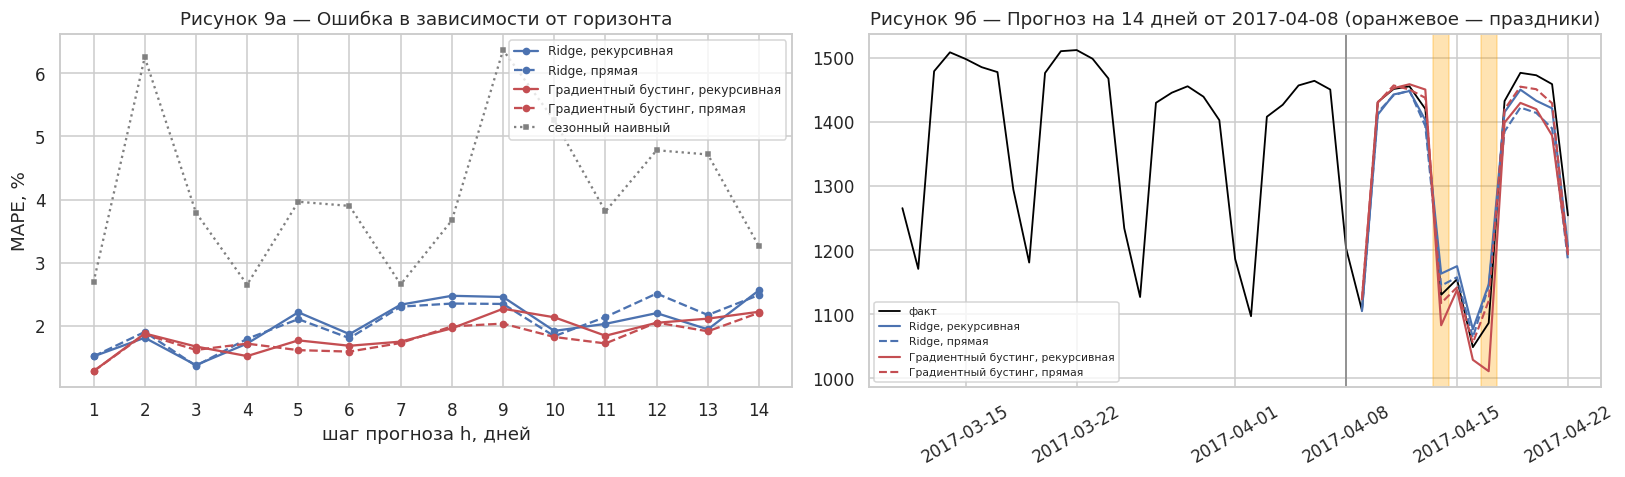

MAPE, % по шагам горизонта:


h,1,2,3,7,8,14
"Ridge, рекурсивная",1.52,1.81,1.38,2.34,2.48,2.56
"Ridge, прямая",1.52,1.90,1.37,2.30,2.35,2.49
"Градиентный бустинг, рекурсивная",1.28,1.88,1.67,1.75,1.96,2.22
"Градиентный бустинг, прямая",1.28,1.87,1.62,1.73,1.99,2.21
сезонный наивный,2.69,6.25,3.79,2.66,3.67,3.26


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
styles = {("Ridge", "рекурсивная"): ("#4C72B0", "-"), ("Ridge", "прямая"): ("#4C72B0", "--"),
          ("Градиентный бустинг", "рекурсивная"): ("#C44E52", "-"),
          ("Градиентный бустинг", "прямая"): ("#C44E52", "--")}
by_h = {}
for (name, strat), (c, ls) in styles.items():
    sub = fc[fc.model == name]
    g = sub.groupby("h").apply(lambda x: metrics(x.y, x[strat])["MAPE, %"])
    by_h[f"{name}, {strat}"] = g
    axes[0].plot(g.index, g.values, ls, color=c, marker="o", ms=4, label=f"{name}, {strat}")
sub = fc[fc.model == "Ridge"]
g = sub.groupby("h").apply(lambda x: metrics(x.y, x["сезонный наивный"])["MAPE, %"])
by_h["сезонный наивный"] = g
axes[0].plot(g.index, g.values, ":", color="gray", marker="s", ms=3, label="сезонный наивный")
axes[0].set_xlabel("шаг прогноза h, дней"); axes[0].set_ylabel("MAPE, %")
axes[0].set_title("Рисунок 9а — Ошибка в зависимости от горизонта"); axes[0].legend(fontsize=8)
axes[0].set_xticks(range(1, H + 1))

# пример одного прогноза: 2 недели от субботы 08.04.2017 (внутри — Страстная пятница и Пасхальный понедельник)
o = pd.Timestamp("2017-04-08")
sub = fc[(fc.origin == o)]
ctx = s[o - pd.Timedelta(days=28):o + pd.Timedelta(days=H)]
axes[1].plot(ctx, color="black", lw=1.2, label="факт")
for (name, strat), (c, ls) in styles.items():
    x = sub[sub.model == name].set_index("date")[strat]
    axes[1].plot(x, ls, color=c, lw=1.4, label=f"{name}, {strat}")
axes[1].axvline(o, color="gray", lw=1)
for d in HOL[o:o + pd.Timedelta(days=H)].index:
    axes[1].axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color="orange", alpha=0.3)
axes[1].set_title(f"Рисунок 9б — Прогноз на {H} дней от {o.date()} (оранжевое — праздники)")
axes[1].legend(fontsize=7); axes[1].tick_params(axis="x", rotation=30)
show(fig, "09_horizon")
print("MAPE, % по шагам горизонта:")
pd.DataFrame(by_h).loc[[1, 2, 3, 7, 8, 14]].round(2).T

**Комментарий к рисунку 9.**

*Слева — ошибка по шагам горизонта.* Общая тенденция — рост: на шаге 1 MAPE бустинга 1,28 %,
на шаге 14 — 2,2 %, у Ridge — с 1,52 % до 2,5–2,6 %. Рост идёт не монотонно, а «зубцами»
с периодом 7: старты прогноза приходятся на субботы, поэтому шаг h всегда соответствует одному
и тому же дню недели. Шаги 2 и 9 — понедельники, на них локальные пики ошибки (переход
от выходных к будням), шаги 3–4 (вторник–среда) — самые лёгкие. Сезонный наивный прогноз (серый) хуже
на всех шагах, особенно на понедельниках (6,25 % на h = 2). На первой неделе стратегии практически
неотличимы; на второй неделе прямая Ridge немного выигрывает у рекурсивной (на шагах 8 и 14:
2,35 и 2,49 % против 2,48 и 2,56 %), у бустинга стратегии остаются близки.

*Справа — пример прогноза* на две недели от 8 апреля 2017 г., внутри которых Страстная пятница
(14.04) и Пасхальный понедельник (17.04). Модели правильно воспроизводят недельную «пилу»
и провалы на праздниках, поскольку праздники известны заранее и входят в календарные признаки.
Глубина провалов воспроизводится неточно, причём в разные стороны: в Страстную пятницу Ridge
и прямой бустинг прогнозируют выше факта, рекурсивный бустинг — ниже; в Пасхальный понедельник
рекурсивный бустинг «проваливается» до ≈ 1 010 ГВт·ч при факте ≈ 1 090. Та же проблема, что
и в разделе 6: один признак `is_holiday` задаёт «средний» праздничный эффект для всех праздников.

# 9. Выводы и ограничения

**Результаты.**

| Задача | Лучшая модель | MAPE | WAPE | Ориентир (сезонный наивный) |
|---|---|---|---|---|
| Прогноз на 1 день | Градиентный бустинг | 1,21 % | 1,19 % | 4,04 % |
| Прогноз на 14 дней | Бустинг, прямая стратегия | 1,80 % | 1,80 % | 4,13 % |

1. **Ряд:** слабый немонотонный тренд (смены уровня в 2009 и 2014 гг.), сильная недельная
   (сила 0,88) и годовая (0,80) сезонность, выбросы почти целиком объясняются праздниками
   (103 из 108 праздников — аномалии).
2. **Сведение к регрессии работает:** 53 признака из календаря, лагов, скользящих статистик
   и годовых лагов позволяют обычной Ridge-регрессии и бустингу обыграть сезонный наивный
   прогноз втрое. Отсутствие утечки проверено формально.
3. **Ridge и бустинг близки** по кросс-валидации (1,67 % и 1,74 %); на тесте бустинг лучше
   (1,21 % против 1,40 %), но у него больше разброс по фолдам и сильное переобучение на train
   (0,51 % на train). Ridge стабильнее и не переобучен.
4. **Главная зона ошибок — праздники** (MAPE 4,1 % против 1,0 % в обычные будни) и понедельники,
   но в сумме ошибка формируется обычными днями (59 %).
5. **STL-признаки не улучшили качество** — информация о компонентах уже содержится в лагах
   и календаре. Декомпозиция полезна как инструмент анализа.
6. **На горизонте 14 дней** ошибка растёт с 1,3 до 2,2 %; прямая и рекурсивная стратегии
   близки, прямая чуть лучше по RMSE (реже крупные промахи).

**Ограничения модели.**

- **Праздники:** один бинарный признак не различает типы праздников и их сочетание с днём
  недели — модель ошибается на них в обе стороны; региональные праздники (Крещение, Тело
  Христово, День всех святых) не учтены.
- **Нет внешних факторов:** потребление зависит от температуры и освещённости, а в данных их нет.
  Погода — главный резерв точности, особенно зимой.
- **Тренд и смены уровня:** бустинг не экстраполирует за пределы обучающих значений; при новом
  сдвиге уровня (кризис, энергосбережение) он будет систематически ошибаться, пока не будет
  переобучен. Ridge в этом смысле надёжнее.
- **Модели в тесте не переобучались;** в реальной эксплуатации их нужно переобучать
  регулярно (например, раз в месяц) на расширяющемся окне.
- **Точечный прогноз:** интервалы неопределённости не строились (можно добавить квантильную
  регрессию или квантили остатков по шагу горизонта).

**Возможные улучшения:** признаки типа праздника и взаимодействия «праздник × день недели»,
погодные данные, гибридная стратегия (прямые модели для шагов 1–7 + рекурсия дальше),
ансамбль Ridge + бустинг.

**Источники**

1. Яндекс Учебник. Временные ряды // Хендбук по машинному обучению. —
   URL: https://contest.yandex.ru/tracks/ml/practical-topics/time-series
2. Hyndman R. J., Athanasopoulos G. Forecasting: Principles and Practice. 3rd ed. — OTexts, 2021. —
   URL: https://otexts.com/fpp3/ (STL-декомпозиция, сила компонент, стратегии прогноза).
3. Bandara K., Hyndman R. J., Bergmeir C. MSTL: A Seasonal-Trend Decomposition Algorithm for Time
   Series with Multiple Seasonal Patterns // arXiv:2107.13462. — 2021.
4. Open Power System Data. Time series. — URL: https://open-power-system-data.org/
5. Документация scikit-learn: TimeSeriesSplit, HistGradientBoostingRegressor. —
   URL: https://scikit-learn.org/stable/
6. Документация statsmodels: STL, MSTL. — URL: https://www.statsmodels.org/stable/